In [1]:
!pip install yfinance

In [31]:
import yfinance as yf
data = yf.download("AAPL", period="5y", interval="1d",auto_adjust=False)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2021-09-07,152.830902,156.690002,157.259995,154.389999,154.970001,82278300
2021-09-08,151.289810,155.110001,157.039993,153.979996,156.979996,74420200
2021-09-09,150.275421,154.070007,156.110001,153.949997,155.490005,57305700
2021-09-10,145.301010,148.970001,155.479996,148.699997,155.000000,140893200
2021-09-13,145.866760,149.550003,151.419998,148.750000,150.630005,102404300


In [32]:
data.to_csv("AAPL_stock_data.csv")

In [33]:
print(data.shape)

(1254, 6)


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-09-07 to 2026-09-03
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1254 non-null   float64
 1   (Close, AAPL)      1254 non-null   float64
 2   (High, AAPL)       1254 non-null   float64
 3   (Low, AAPL)        1254 non-null   float64
 4   (Open, AAPL)       1254 non-null   float64
 5   (Volume, AAPL)     1254 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.6 KB


In [35]:
data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,199.914002,201.943764,203.961157,199.723102,201.720128,6.422656e+07
std,49.290425,48.408014,48.780067,47.943436,48.310040,2.868158e+07
min,122.827621,125.019997,127.769997,124.169998,126.010002,1.791060e+07
25%,161.719936,165.032505,166.362503,163.002499,164.617496,4.515302e+07
50%,187.583061,189.779999,191.065002,188.520004,189.644997,5.581925e+07
75%,231.677883,233.264999,235.089996,230.372494,233.327503,7.606822e+07
max,339.786926,340.079987,344.570007,337.350006,340.029999,3.186799e+08


In [36]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2021-09-07,152.830902,156.690002,157.259995,154.389999,154.970001,82278300
2021-09-08,151.289810,155.110001,157.039993,153.979996,156.979996,74420200
2021-09-09,150.275421,154.070007,156.110001,153.949997,155.490005,57305700
2021-09-10,145.301010,148.970001,155.479996,148.699997,155.000000,140893200
2021-09-13,145.866760,149.550003,151.419998,148.750000,150.630005,102404300


In [37]:
data.isnull().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [38]:
data.isnull().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


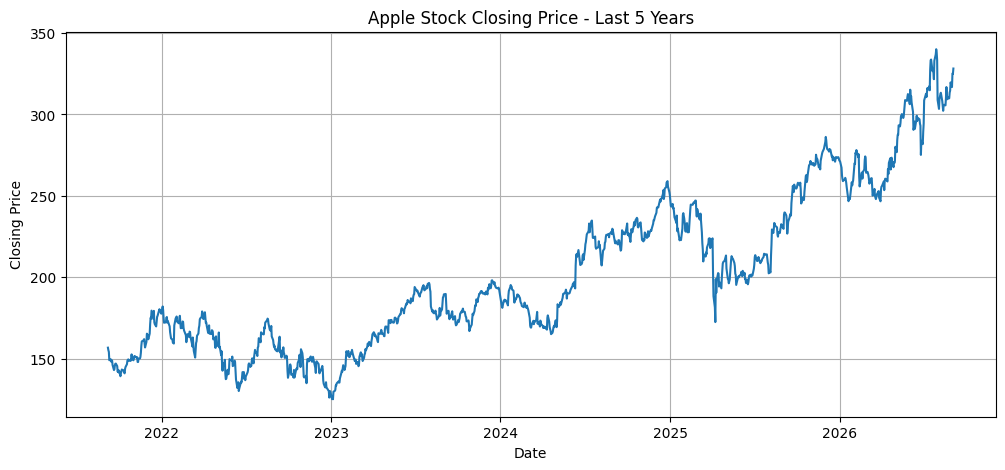

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(data.index, data["Close"])
plt.title("Apple Stock Closing Price - Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [40]:
df = data[["Close"]].copy()

df["Previous_Close"] = df["Close"].shift(1)

df = df.dropna()

df.head()

Price,Close,Previous_Close
Ticker,AAPL,
Date,,
2021-09-08,155.110001,156.690002
2021-09-09,154.070007,155.110001
2021-09-10,148.970001,154.070007
2021-09-13,149.550003,148.970001
2021-09-14,148.119995,149.550003


In [41]:
X = df[["Previous_Close"]]
y = df["Close"]

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (1253, 1)
Y shape: (1253, 1)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 1002
Testing data: 251


In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [44]:
predictions = model.predict(X_test)

print("First 10 predictions:")
print(predictions[:10])

First 10 predictions:
[[239.62777462]
 [239.53815017]
 [237.73563198]
 [234.22022006]
 [226.69144715]
 [229.91806411]
 [233.94137831]
 [236.56050014]
 [238.00450533]
 [238.84104578]]


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 3.159285425193753
Root Mean Squared Error: 4.487047072300071
R² Score: 0.967853475596066


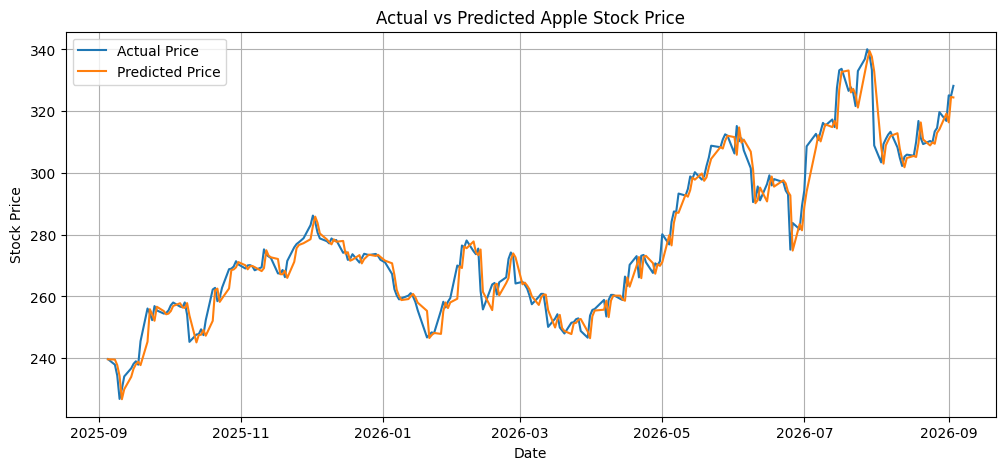

In [46]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test.values, label="Actual Price")
plt.plot(y_test.index, predictions, label="Predicted Price")

plt.title("Actual vs Predicted Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
previous_price = float(input("Enter previous closing price: "))

predicted_price = model.predict([[previous_price]])

print("Predicted next closing price:", predicted_price[0])

In [ ]:
df.to_csv("AAPL_processed_data.csv")

print("Processed dataset saved successfully!")